In [69]:
import pandas as pd

In [70]:
df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

In [71]:
print(df.head)

<bound method NDFrame.head of               State  Year  Total_Flood_Events  Total_Fatalities  \
0    Andhra Pradesh  2001                 0.0               0.0   
1    Andhra Pradesh  2002                 0.0               0.0   
2    Andhra Pradesh  2003                 0.0               0.0   
3    Andhra Pradesh  2004                 2.0              14.0   
4    Andhra Pradesh  2005                 1.0               9.0   
..              ...   ...                 ...               ...   
635     West Bengal  2016                 0.0               0.0   
636     West Bengal  2017                 1.0              32.0   
637     West Bengal  2018                 0.0               0.0   
638     West Bengal  2019                 2.0             222.0   
639     West Bengal  2020                 2.0             142.0   

     Mean_Duration_Days  Annual_Tree_Loss_ha  Annual_Percent_Tree_Loss  \
0                   0.0               1098.4                  0.099321   
1                

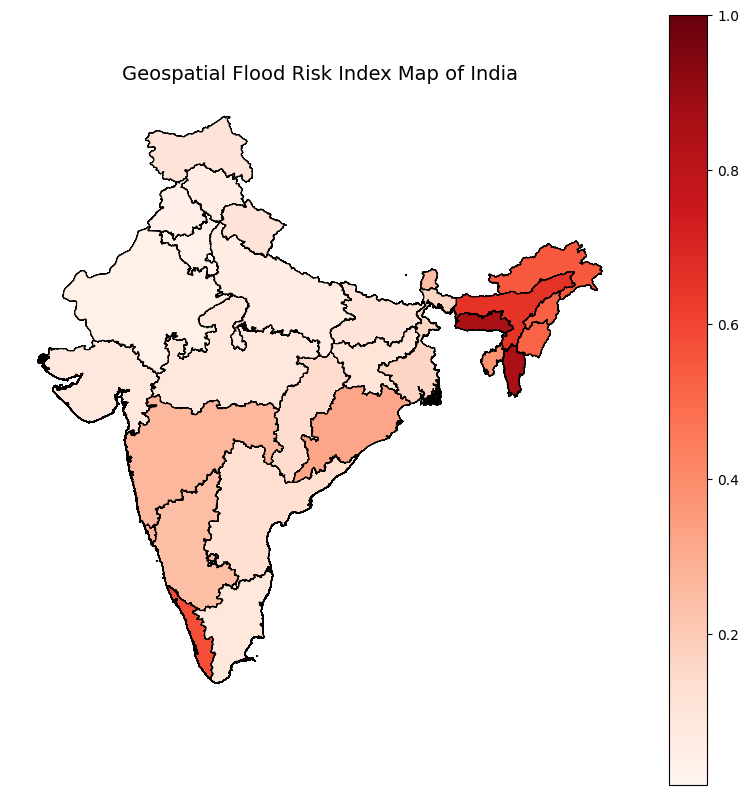

In [72]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# STEP 1: Select features
# -----------------------------
features = [
    "Annual_Rainfall",
    "Annual_Tree_Loss_ha",
    "Lagged_Annual_Tree_Loss_ha",
    "Total_Flood_Events"
]

# -----------------------------
# STEP 2: Normalize variables
# -----------------------------
scaler = MinMaxScaler()

df_norm = pd.DataFrame(
    scaler.fit_transform(df[features]),
    columns=[
        "Rainfall_norm",
        "TreeLoss_norm",
        "LagTreeLoss_norm",
        "FloodEvents_norm"
    ]
)

df = pd.concat([df, df_norm], axis=1)

# -----------------------------
# STEP 3: Compute Flood Risk Index
# -----------------------------
df["Flood_Risk_Index"] = (
    0.30 * df["TreeLoss_norm"] +
    0.25 * df["LagTreeLoss_norm"] +
    0.30 * df["Rainfall_norm"] +
    0.15 * df["FloodEvents_norm"]
)

# Normalize final index (0–1)
df["Flood_Risk_Index"] = (
    df["Flood_Risk_Index"] - df["Flood_Risk_Index"].min()
) / (
    df["Flood_Risk_Index"].max() - df["Flood_Risk_Index"].min()
)

# -----------------------------
# STEP 4: Load India shapefile
# -----------------------------
india_map = gpd.read_file("gadm41_IND_1.shp")
india_map = india_map.rename(columns={"NAME_1": "State"})
# Merge J&K and Ladakh in shapefile
# Standardize names first
india_map["State"] = india_map["State"].str.strip()

# Fix naming differences
india_map["State"] = india_map["State"].replace({
    "Jammu and Kashmir": "Jammu & Kashmir",
    "Ladakh": "Jammu & Kashmir"
})
india_map["State"] = india_map["State"].replace({
    "Telangana": "Andhra Pradesh"
})

# Now dissolve
india_map = india_map.dissolve(by="State", as_index=False)


# -----------------------------
# STEP 5: Merge data
# -----------------------------
merged = india_map.merge(df, on="State", how="left")

# -----------------------------
# STEP 6: Plot map
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="Flood_Risk_Index",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)


# Title
ax.set_title("Geospatial Flood Risk Index Map of India", fontsize=14)

# Remove axis
ax.axis("off")

plt.show()

In [25]:
# Drop first year (no lag data)
df_ml = df[df["Year"] > 2001].copy()

# Drop any remaining NA rows
df_ml = df_ml.dropna()

print(df_ml.shape)

(608, 15)


In [26]:
import numpy as np

# Log transform skewed features
df_ml["log_rainfall"] = np.log1p(df_ml["Annual_Rainfall"])
df_ml["log_monsoon"] = np.log1p(df_ml["Monsoon_Rainfall"])
df_ml["log_max_rain"] = np.log1p(df_ml["Max_Daily_Rainfall"])
df_ml["log_lag_rain"] = np.log1p(df_ml["Lagged_Annual_Rainfall"])

# Target variable
df_ml["log_flood"] = np.log1p(df_ml["Total_Flood_Events"])

In [27]:
features = [
    "log_rainfall",
    "log_monsoon",
    "log_max_rain",
    "Annual_Percent_Tree_Loss",
    "Lagged_Annual_Percent_Tree_Loss",
    "log_lag_rain"
]

X = df_ml[features]

y = df_ml["log_flood"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,8
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
from sklearn.metrics import r2_score, mean_absolute_error

preds = rf_model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.24077329246032664
MAE: 0.532126449702232


In [31]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                           Feature  Importance
2                     log_max_rain    0.204225
3         Annual_Percent_Tree_Loss    0.185923
4  Lagged_Annual_Percent_Tree_Loss    0.163114
1                      log_monsoon    0.155296
5                     log_lag_rain    0.147261
0                     log_rainfall    0.144182


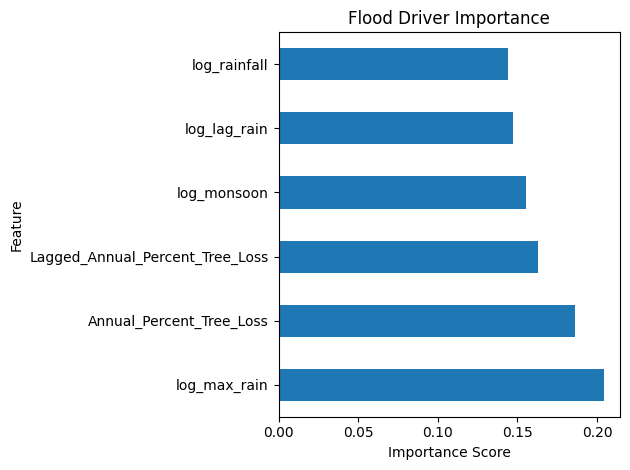

In [32]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False
)

plt.title("Flood Driver Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [34]:
from xgboost import XGBRegressor

In [35]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
from sklearn.metrics import r2_score, mean_absolute_error

xgb_preds = xgb_model.predict(X_test)

r2 = r2_score(y_test, xgb_preds)
mae = mean_absolute_error(y_test, xgb_preds)

print("XGBoost R2:", r2)
print("XGBoost MAE:", mae)

XGBoost R2: 0.2614581933960993
XGBoost MAE: 0.507036515010078


In [37]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                           Feature  Importance
4  Lagged_Annual_Percent_Tree_Loss    0.262886
3         Annual_Percent_Tree_Loss    0.252458
2                     log_max_rain    0.140659
0                     log_rainfall    0.117390
5                     log_lag_rain    0.114186
1                      log_monsoon    0.112420


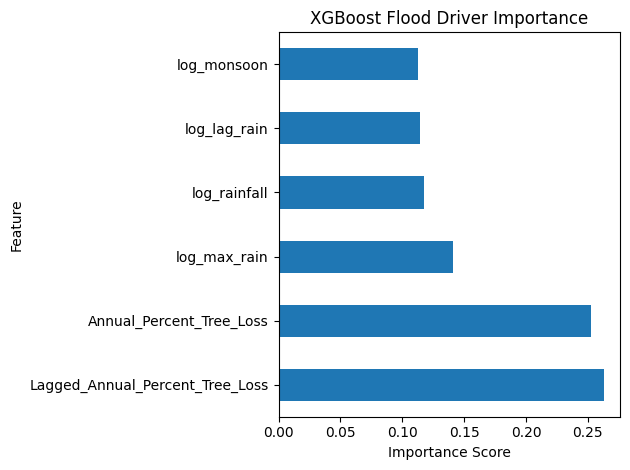

In [38]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False
)

plt.title("XGBoost Flood Driver Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

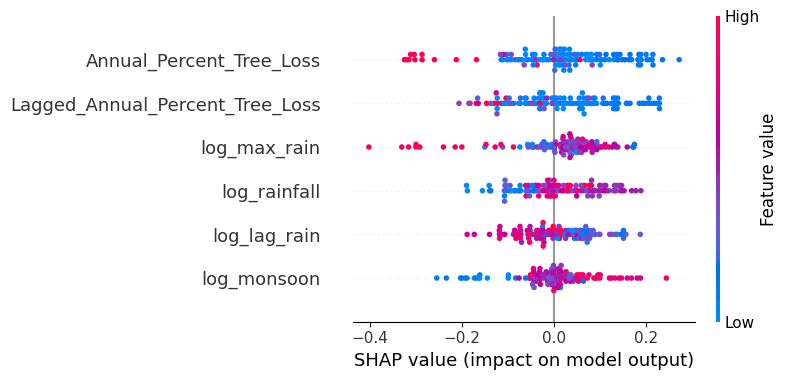

In [55]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

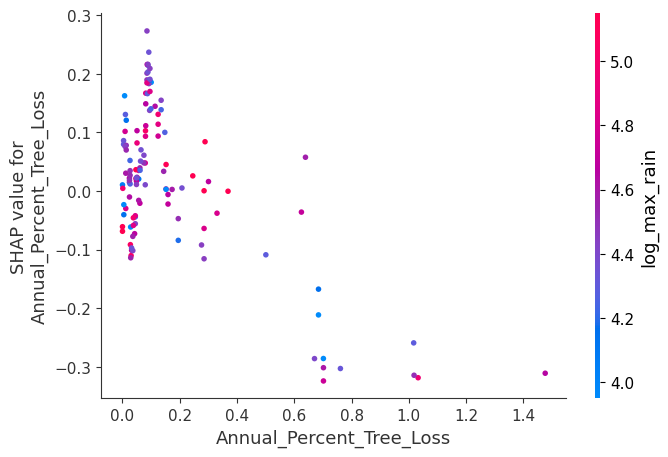

In [57]:
shap.dependence_plot(
    "Annual_Percent_Tree_Loss",
    shap_values,
    X_test
)